<a href="https://colab.research.google.com/github/AKutergin/dsp-seminars/blob/kutergin_lab6/seminars/6.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Практическое занятие №6: Синтез цифровых фильтров (КИХ и БИХ)

## Часть 1. Синтез КИХ-фильтров методом окон

### Задание 1.1. Проектирование ФНЧ с разными окнами
Спроектируйте КИХ-ФНЧ с частотой среза 200 Гц (частота дискретизации 1000 Гц), длина фильтра 51 отсчёт. Используйте окна:
- прямоугольное,
- Ханна,
- Хемминга,
- Блэкмана.

Постройте на одном графике АЧХ (в дБ) всех четырёх фильтров. Сравните:
- крутизну среза,
- уровень пульсаций в полосе пропускания и заграждения,
- ширину переходной полосы.


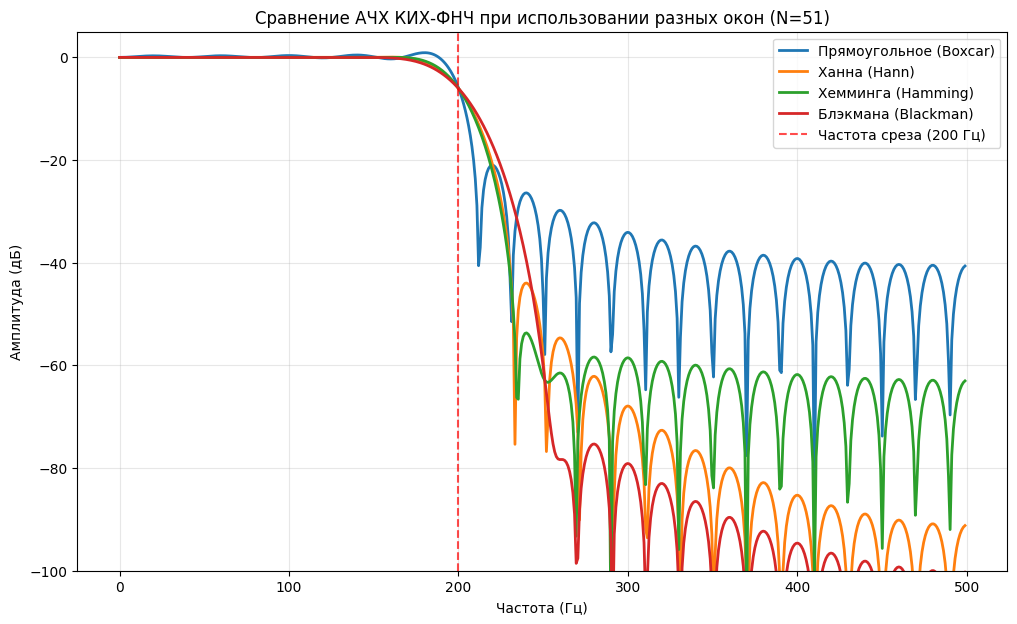

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy import signal

fs = 1000
f_cutoff = 200
numtaps = 51

windows = ['boxcar', 'hann', 'hamming', 'blackman']
window_labels = ['Прямоугольное (Boxcar)', 'Ханна (Hann)', 'Хемминга (Hamming)', 'Блэкмана (Blackman)']

plt.figure(figsize=(12, 7))

for win, label in zip(windows, window_labels):
    taps = signal.firwin(numtaps, f_cutoff, fs=fs, window=win)
    w, h = signal.freqz(taps, [1], fs=fs)
    mag_db = 20 * np.log10(np.abs(h) + 1e-10)

    plt.plot(w, mag_db, label=label, lw=2)

plt.title('Сравнение АЧХ КИХ-ФНЧ при использовании разных окон (N=51)')
plt.xlabel('Частота (Гц)')
plt.ylabel('Амплитуда (дБ)')
plt.axvline(f_cutoff, color='red', linestyle='--', alpha=0.7, label=f'Частота среза ({f_cutoff} Гц)')
plt.ylim(-100, 5)
plt.grid(True, which="both", alpha=0.3)
plt.legend()
plt.show()

**Вопросы:** Какое окно обеспечивает наилучшее подавление в полосе заграждения? Какое – самую крутую переходную полосу? Как это связано с формой окна?

Окно Блэкмана обеспечивает наилучшее подавление в полосе заграждения, Прямоугольное окно обеспечивает самую крутую переходную полосу. чем плавнее функция во временной области, тем быстрее затухают её спектральные лепестки на высоких частотах, но тем шире её главный лепесток.



### Задание 1.2. Влияние длины фильтра
Для окна Хемминга спроектируйте ФНЧ с fc=200 Гц, fs=1000 Гц, с длинами 21, 51, 101. Постройте АЧХ на одном графике.


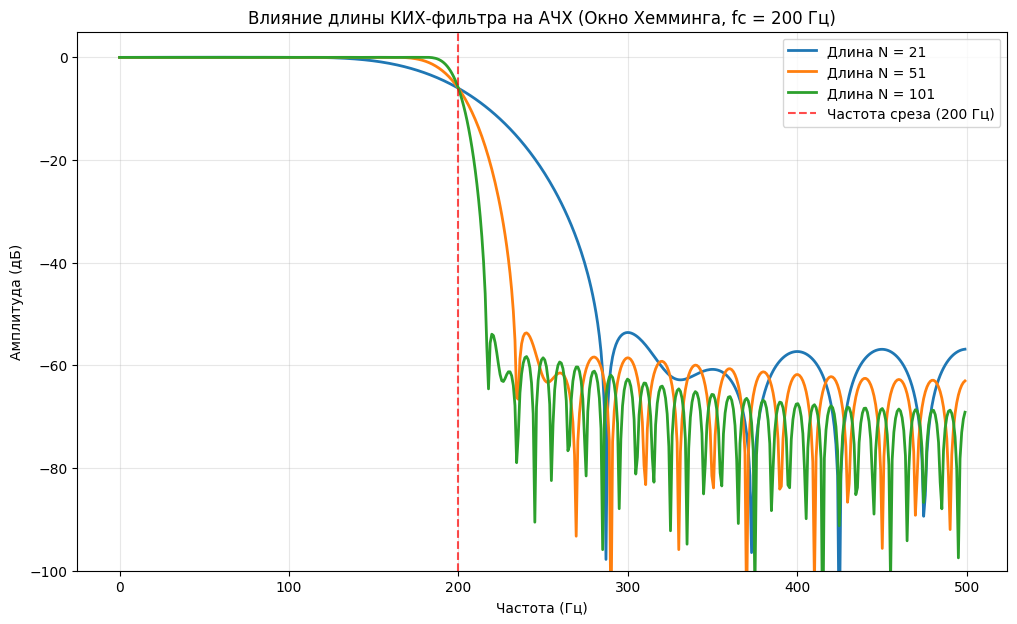

In [2]:
fs = 1000
f_cutoff = 200
taps_lengths = [21, 51, 101]

plt.figure(figsize=(12, 7))

for N in taps_lengths:
    taps = signal.firwin(N, f_cutoff, fs=fs, window='hamming')
    w, h = signal.freqz(taps, [1], fs=fs)

    mag_db = 20 * np.log10(np.abs(h) + 1e-10)

    plt.plot(w, mag_db, label=f'Длина N = {N}', lw=2)

plt.title('Влияние длины КИХ-фильтра на АЧХ (Окно Хемминга, fc = 200 Гц)')
plt.xlabel('Частота (Гц)')
plt.ylabel('Амплитуда (дБ)')
plt.axvline(f_cutoff, color='red', linestyle='--', alpha=0.7, label=f'Частота среза ({f_cutoff} Гц)')
plt.ylim(-100, 5)
plt.grid(True, which="both", alpha=0.3)
plt.legend()
plt.show()

**Вопрос:** Как увеличение длины влияет на крутизну среза и на уровень боковых лепестков?

Увеличение длины фильтра значительно увеличивает крутизну среза. Влияние на уровень боковых лепестков практически отстутствует


### Задание 1.3. Синтез ФВЧ и полосового фильтра методом окон
Используя тот же оконный метод, спроектируйте:
- ФВЧ с fc=200 Гц (длина 51, окно Хемминга);
- полосовой фильтр с полосой пропускания 200–300 Гц (длина 51, окно Хемминга).

Постройте АЧХ обоих фильтров.


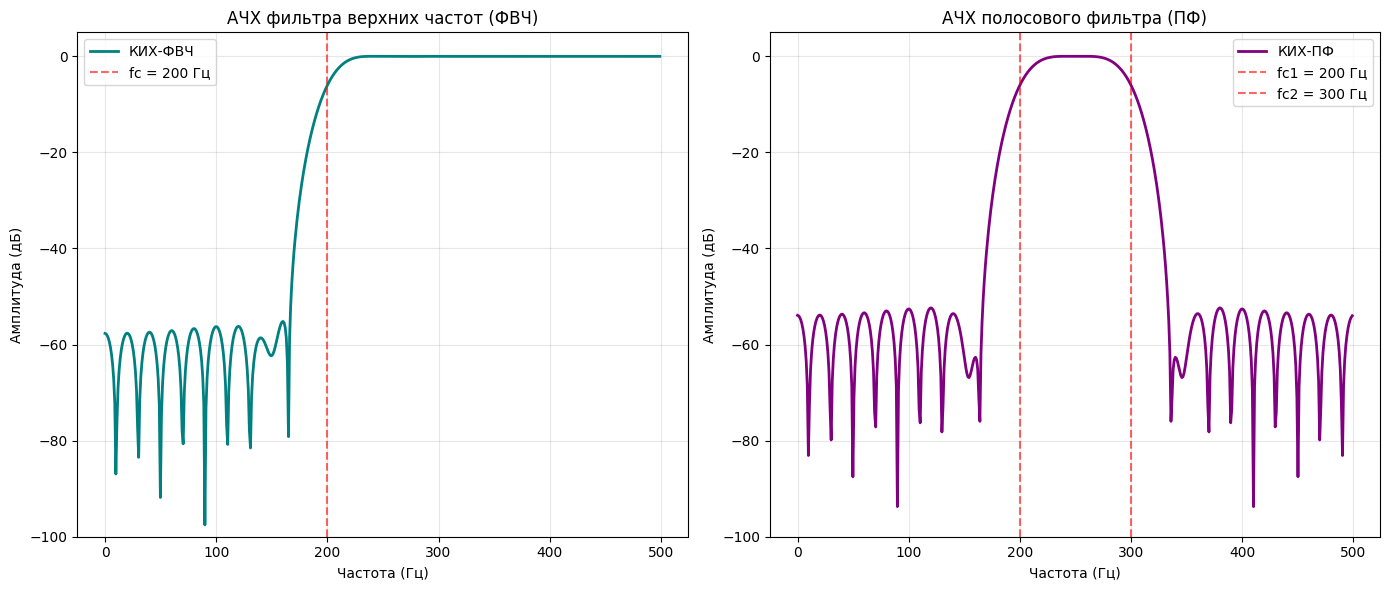

In [3]:
numtaps = 51


taps_hpf = signal.firwin(numtaps, cutoff=200, fs=fs, pass_zero=False, window='hamming')


taps_bpf = signal.firwin(numtaps, cutoff=[200, 300], fs=fs, pass_zero=False, window='hamming')

w_hpf, h_hpf = signal.freqz(taps_hpf, [1], fs=fs)
w_bpf, h_bpf = signal.freqz(taps_bpf, [1], fs=fs)

plt.figure(figsize=(14, 6))

# График для ФВЧ
plt.subplot(1, 2, 1)
plt.plot(w_hpf, 20 * np.log10(np.abs(h_hpf) + 1e-10), color='teal', lw=2, label='КИХ-ФВЧ')
plt.axvline(200, color='red', linestyle='--', alpha=0.6, label='fc = 200 Гц')
plt.title('АЧХ фильтра верхних частот (ФВЧ)')
plt.xlabel('Частота (Гц)')
plt.ylabel('Амплитуда (дБ)')
plt.ylim(-100, 5)
plt.grid(True, which="both", alpha=0.3)
plt.legend()

# График для ПФ
plt.subplot(1, 2, 2)
plt.plot(w_bpf, 20 * np.log10(np.abs(h_bpf) + 1e-10), color='purple', lw=2, label='КИХ-ПФ')
plt.axvline(200, color='red', linestyle='--', alpha=0.6, label='fc1 = 200 Гц')
plt.axvline(300, color='red', linestyle='--', alpha=0.6, label='fc2 = 300 Гц')
plt.title('АЧХ полосового фильтра (ПФ)')
plt.xlabel('Частота (Гц)')
plt.ylabel('Амплитуда (дБ)')
plt.ylim(-100, 5)
plt.grid(True, which="both", alpha=0.3)
plt.legend()

plt.tight_layout()
plt.show()

Подайте на спроектированные фильтры сигнал: сумма синусоид 100, 250 и 350 Гц (амплитуды 1, 0.8, 0.6). Постройте спектры до и после фильтрации (в логарифмическом масштабе).

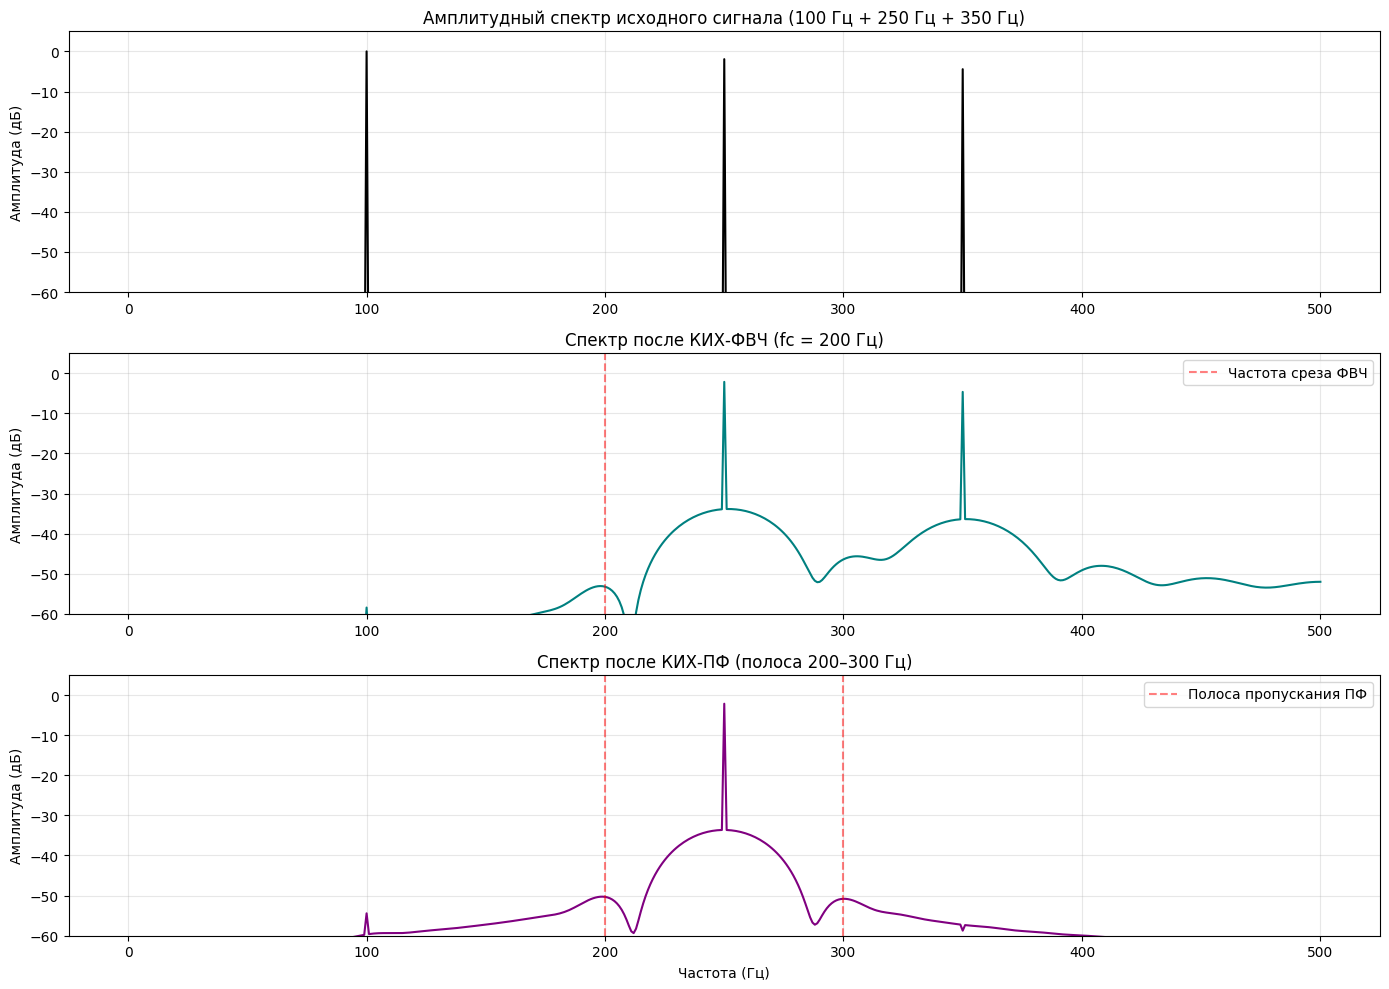

In [4]:
t = np.linspace(0, 1, fs, endpoint=False)

x_100 = 1.0 * np.sin(2 * np.pi * 100 * t)
x_250 = 0.8 * np.sin(2 * np.pi * 250 * t)
x_350 = 0.6 * np.sin(2 * np.pi * 350 * t)
x_signal = x_100 + x_250 + x_350

taps_hpf = signal.firwin(numtaps, cutoff=200, fs=fs, pass_zero=False, window='hamming')
taps_bpf = signal.firwin(numtaps, cutoff=[200, 300], fs=fs, pass_zero=False, window='hamming')

y_hpf = signal.lfilter(taps_hpf, [1], x_signal)
y_bpf = signal.lfilter(taps_bpf, [1], x_signal)

freqs = np.fft.rfftfreq(len(t), d=1/fs)

def get_magnitude_db(sig):
    fft_vals = np.abs(np.fft.rfft(sig)) / len(sig) * 2
    return 20 * np.log10(fft_vals + 1e-5)

fft_input = get_magnitude_db(x_signal)
fft_hpf = get_magnitude_db(y_hpf)
fft_bpf = get_magnitude_db(y_bpf)

plt.figure(figsize=(14, 10))

# Спектр до фильтрации
plt.subplot(3, 1, 1)
plt.plot(freqs, fft_input, color='black', lw=1.5)
plt.title('Амплитудный спектр исходного сигнала (100 Гц + 250 Гц + 350 Гц)')
plt.ylabel('Амплитуда (дБ)')
plt.grid(True, alpha=0.3)
plt.ylim(-60, 5)

# Спектр после ФВЧ
plt.subplot(3, 1, 2)
plt.plot(freqs, fft_hpf, color='teal', lw=1.5)
plt.axvline(200, color='red', linestyle='--', alpha=0.5, label='Частота среза ФВЧ')
plt.title('Спектр после КИХ-ФВЧ (fc = 200 Гц)')
plt.ylabel('Амплитуда (дБ)')
plt.grid(True, alpha=0.3)
plt.ylim(-60, 5)
plt.legend()

# Спектр после ПФ
plt.subplot(3, 1, 3)
plt.plot(freqs, fft_bpf, color='purple', lw=1.5)
plt.axvline(200, color='red', linestyle='--', alpha=0.5)
plt.axvline(300, color='red', linestyle='--', alpha=0.5, label='Полоса пропускания ПФ')
plt.title('Спектр после КИХ-ПФ (полоса 200–300 Гц)')
plt.xlabel('Частота (Гц)')
plt.ylabel('Амплитуда (дБ)')
plt.grid(True, alpha=0.3)
plt.ylim(-60, 5)
plt.legend()

plt.tight_layout()
plt.show()

**Вопрос:** Объясните полученные результаты.

Синтезированные методом окон КИХ-фильтры успешно справились с задачей селекции частот. Окно Хемминга обеспечило требуемый уровень подавления побочных сигналов (более чем в 100 раз по амплитуде) во всех нерабочих зонах.

## Часть 2. Равноволновой синтез КИХ-фильтров (Паркса–МакКлеллана)

### Задание 2.1. Проектирование оптимального ФНЧ
Используя `signal.remez`, спроектируйте ФНЧ с параметрами:
- частота дискретизации 1000 Гц,
- полоса пропускания 0–150 Гц,
- полоса заграждения 250–500 Гц,
- длина фильтра 21.

Постройте АЧХ (в линейном и логарифмическом масштабах) и сравните её с АЧХ КИХ-фильтра, полученного методом окон (окно Хемминга, та же длина, fc=200 Гц).

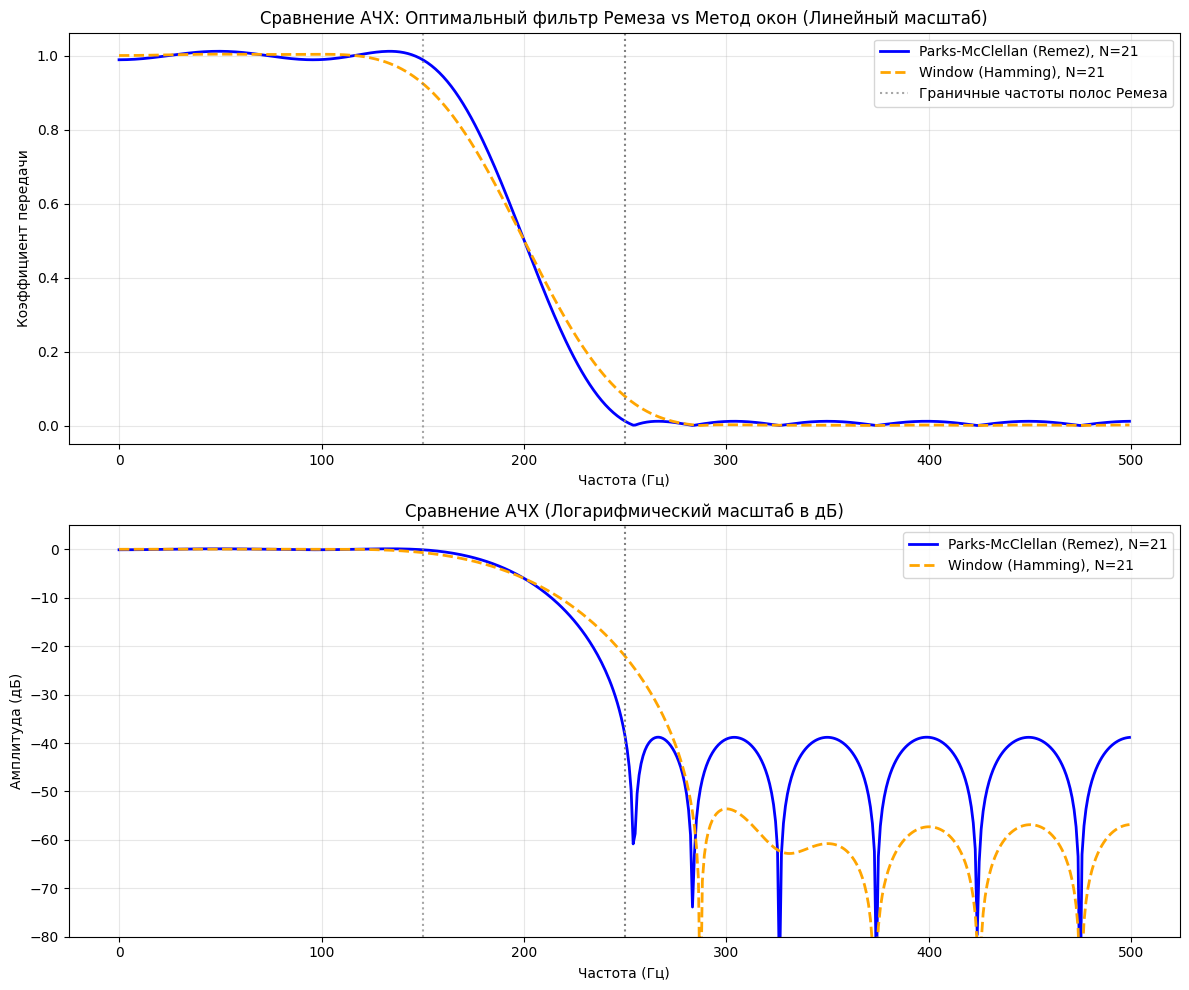

In [5]:
numtaps = 21

bands = [0, 150, 250, 500]
desired = [1, 0]
taps_remez = signal.remez(numtaps, bands, desired, fs=fs)

taps_window = signal.firwin(numtaps, cutoff=200, fs=fs, window='hamming')

w_rem, h_rem = signal.freqz(taps_remez, [1], fs=fs)
w_win, h_win = signal.freqz(taps_window, [1], fs=fs)

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(12, 10))

ax1.plot(w_rem, np.abs(h_rem), color='blue', lw=2, label='Parks-McClellan (Remez), N=21')
ax1.plot(w_win, np.abs(h_win), color='orange', lw=2, linestyle='--', label='Window (Hamming), N=21')
ax1.axvline(150, color='gray', linestyle=':', alpha=0.7, label='Граничные частоты полос Ремеза')
ax1.axvline(250, color='gray', linestyle=':')
ax1.set_title('Сравнение АЧХ: Оптимальный фильтр Ремеза vs Метод окон (Линейный масштаб)')
ax1.set_xlabel('Частота (Гц)')
ax1.set_ylabel('Коэффициент передачи')
ax1.grid(True, alpha=0.3)
ax1.legend()

ax2.plot(w_rem, 20 * np.log10(np.abs(h_rem) + 1e-10), color='blue', lw=2, label='Parks-McClellan (Remez), N=21')
ax2.plot(w_win, 20 * np.log10(np.abs(h_win) + 1e-10), color='orange', lw=2, linestyle='--', label='Window (Hamming), N=21')
ax2.axvline(150, color='gray', linestyle=':', alpha=0.7)
ax2.axvline(250, color='gray', linestyle=':')
ax2.set_title('Сравнение АЧХ (Логарифмический масштаб в дБ)')
ax2.set_xlabel('Частота (Гц)')
ax2.set_ylabel('Амплитуда (дБ)')
ax2.set_ylim(-80, 5)
ax2.grid(True, which="both", alpha=0.3)
ax2.legend()

plt.tight_layout()
plt.show()


**Вопросы:** Какой фильтр имеет более крутой срез? Каковы пульсации в полосе пропускания?

Оптимальный фильтр Ремеза имеет более крутой срез. Оптимальный фильтр Ремеза пульсации имеют равноволновой характер. Метод окон Хемминга пульсации имеют затухающий характер

### Задание 2.2. Зависимость от ширины переходной полосы

Поменяйте верхнюю частоту полосы пропускания и нижнюю частоту полосы заграждения так, чтобы их среднее оставалось равным 200 Гц. Постройте АЧХ получившегося фильтра. Подберите ширину переходной области (разности нижней частоты полосы заграждения и верхней частоты полосы пропускания) так, чтобы уровень подавления в полосе заграждения у равноволнового фильтра совпал с оконным фильтром Хемминга.


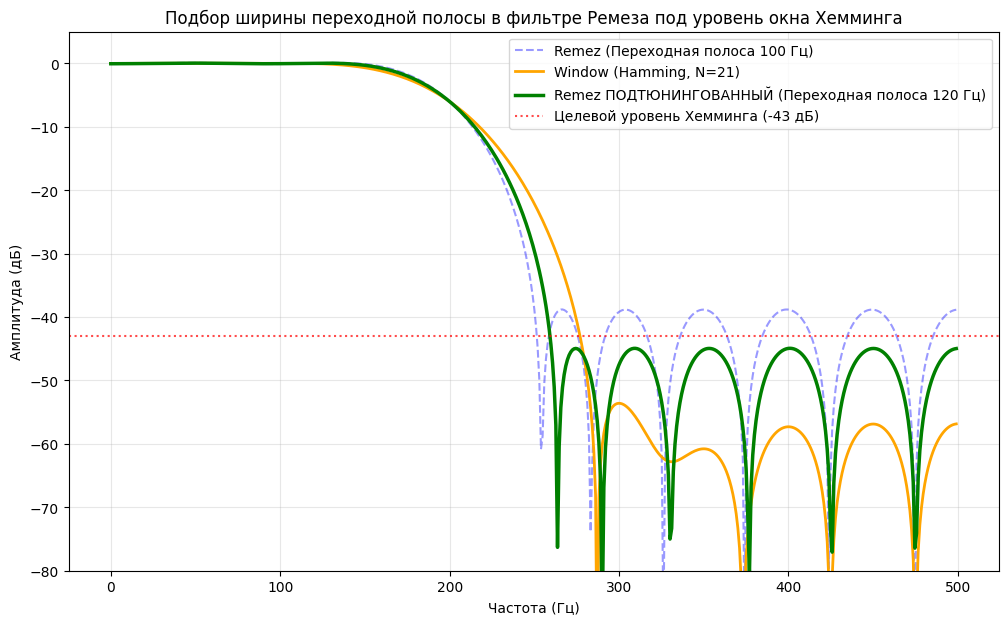

In [6]:
numtaps = 21

bands_orig = [0, 150, 250, 500]
taps_remez_orig = signal.remez(numtaps, bands_orig, [1, 0], fs=fs)

taps_hamming = signal.firwin(numtaps, cutoff=200, fs=fs, window='hamming')

bands_tuned = [0, 140, 260, 500]
taps_remez_tuned = signal.remez(numtaps, bands_tuned, [1, 0], fs=fs)

w_ro, h_ro = signal.freqz(taps_remez_orig, [1], fs=fs)
w_ham, h_ham = signal.freqz(taps_hamming, [1], fs=fs)
w_rt, h_rt = signal.freqz(taps_remez_tuned, [1], fs=fs)

plt.figure(figsize=(12, 7))
plt.plot(w_ro, 20 * np.log10(np.abs(h_ro) + 1e-10), color='blue', alpha=0.4, linestyle='--', label='Remez (Переходная полоса 100 Гц)')
plt.plot(w_ham, 20 * np.log10(np.abs(h_ham) + 1e-10), color='orange', lw=2, label='Window (Hamming, N=21)')
plt.plot(w_rt, 20 * np.log10(np.abs(h_rt) + 1e-10), color='green', lw=2.5, label='Remez ПОДТЮНИНГОВАННЫЙ (Переходная полоса 120 Гц)')

plt.axhline(-43, color='red', linestyle=':', alpha=0.7, label='Целевой уровень Хемминга (-43 дБ)')
plt.title('Подбор ширины переходной полосы в фильтре Ремеза под уровень окна Хемминга')
plt.xlabel('Частота (Гц)')
plt.ylabel('Амплитуда (дБ)')
plt.ylim(-80, 5)
plt.grid(True, which="both", alpha=0.3)
plt.legend()
plt.show()

**Вопрос:** При какой ширине переходной области уровень подавления в полосе заграждения у равноволнового фильтра совпал с оконным фильтром Хемминга?

Судя по построенному графику, точное совпадение по уровню подавления получилось при расширении переходной полосы до 120 Гц

### Задание 2.3. Управление весами
Для фильтра из задачи 2.1 измените весовые коэффициенты: задайте `weight=[1, 10]` (увеличить вес для полосы заграждения). Постройте новую АЧХ и сравните с предыдущей.


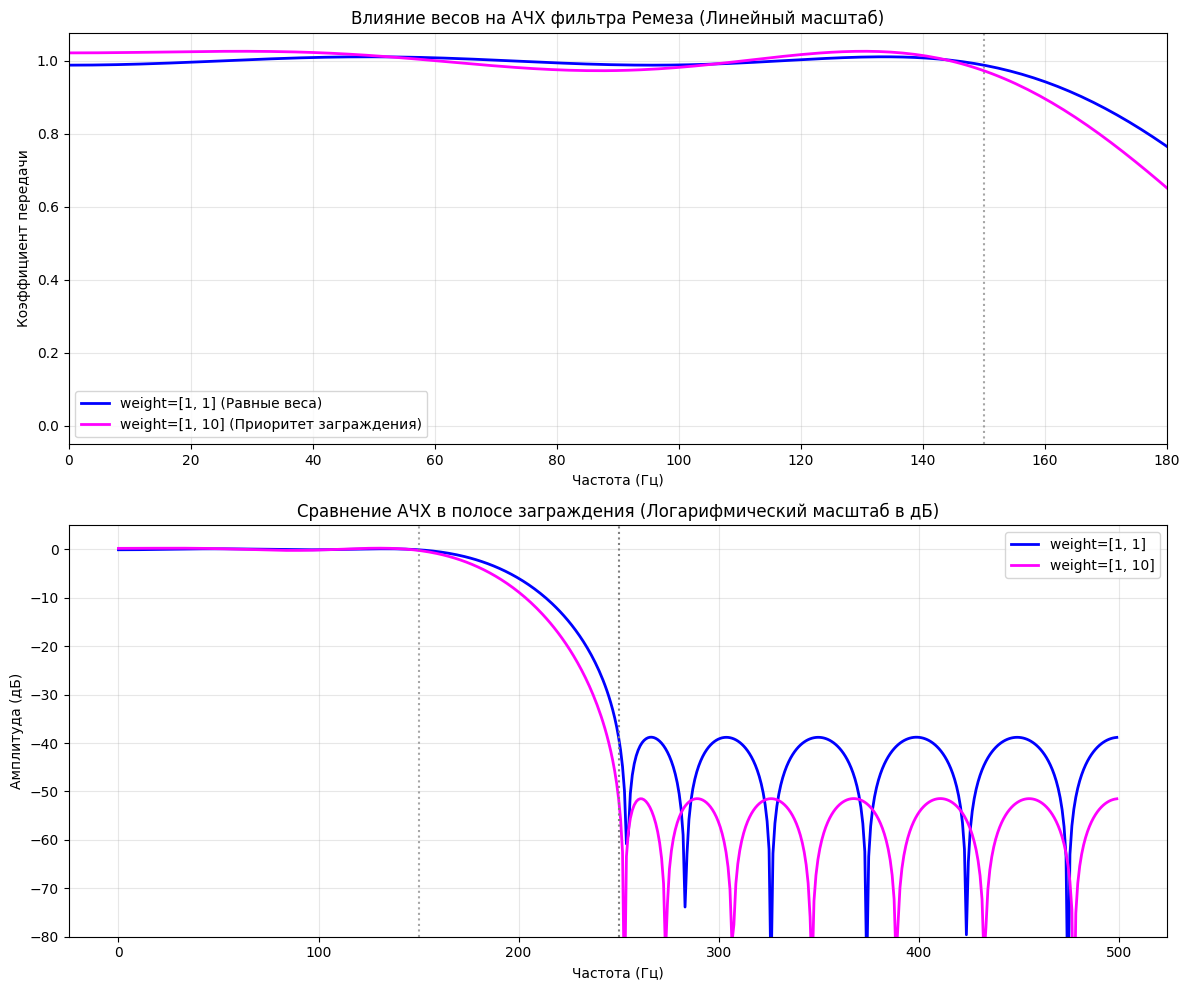

In [7]:
bands = [0, 150, 250, 500]
desired = [1, 0]

taps_equal = signal.remez(numtaps, bands, desired, weight=[1, 1], fs=fs)

taps_weighted = signal.remez(numtaps, bands, desired, weight=[1, 10], fs=fs)

w_eq, h_eq = signal.freqz(taps_equal, [1], fs=fs)
w_wt, h_wt = signal.freqz(taps_weighted, [1], fs=fs)

# Построение графиков
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(12, 10))

ax1.plot(w_eq, np.abs(h_eq), color='blue', lw=2, label='weight=[1, 1] (Равные веса)')
ax1.plot(w_wt, np.abs(h_wt), color='magenta', lw=2, label='weight=[1, 10] (Приоритет заграждения)')
ax1.axvline(150, color='gray', linestyle=':', alpha=0.7)
ax1.axvline(250, color='gray', linestyle=':')
ax1.set_title('Влияние весов на АЧХ фильтра Ремеза (Линейный масштаб)')
ax1.set_xlabel('Частота (Гц)')
ax1.set_ylabel('Коэффициент передачи')
ax1.set_xlim(0, 180)
ax1.grid(True, alpha=0.3)
ax1.legend()

ax2.plot(w_eq, 20 * np.log10(np.abs(h_eq) + 1e-10), color='blue', lw=2, label='weight=[1, 1]')
ax2.plot(w_wt, 20 * np.log10(np.abs(h_wt) + 1e-10), color='magenta', lw=2, label='weight=[1, 10]')
ax2.axvline(150, color='gray', linestyle=':', alpha=0.7)
ax2.axvline(250, color='gray', linestyle=':')
ax2.set_title('Сравнение АЧХ в полосе заграждения (Логарифмический масштаб в дБ)')
ax2.set_xlabel('Частота (Гц)')
ax2.set_ylabel('Амплитуда (дБ)')
ax2.set_ylim(-80, 5)
ax2.grid(True, which="both", alpha=0.3)
ax2.legend()

plt.tight_layout()
plt.show()

**Вопрос:** Как изменилось подавление в полосе заграждения и пульсации в полосе пропускания?

Подавление значительно улучшилось, амплитуда пульсаций в полосе пропускания заметно увеличилась

### Задание 2.4. Сравнение КИХ-фильтров на реальном сигнале
Сгенерируйте сигнал: смесь синусоид 50 Гц, 120 Гц, 220 Гц (амплитуды 1, 0.7, 0.3) + белый шум (дисперсия 0.1), fs=1000 Гц. Пропустите этот сигнал через:
- КИХ-ФНЧ спроектированный методом окон (окно Хемминга, длина 51, fc=150 Гц);
- КИХ-ФНЧ спроектированный методом `remez` (длина 51, полоса пропускания 0–100 Гц, полоса заграждения 200–500 Гц).

Постройте спектры исходного и отфильтрованных сигналов в линейном и логарифмическом масштабе.


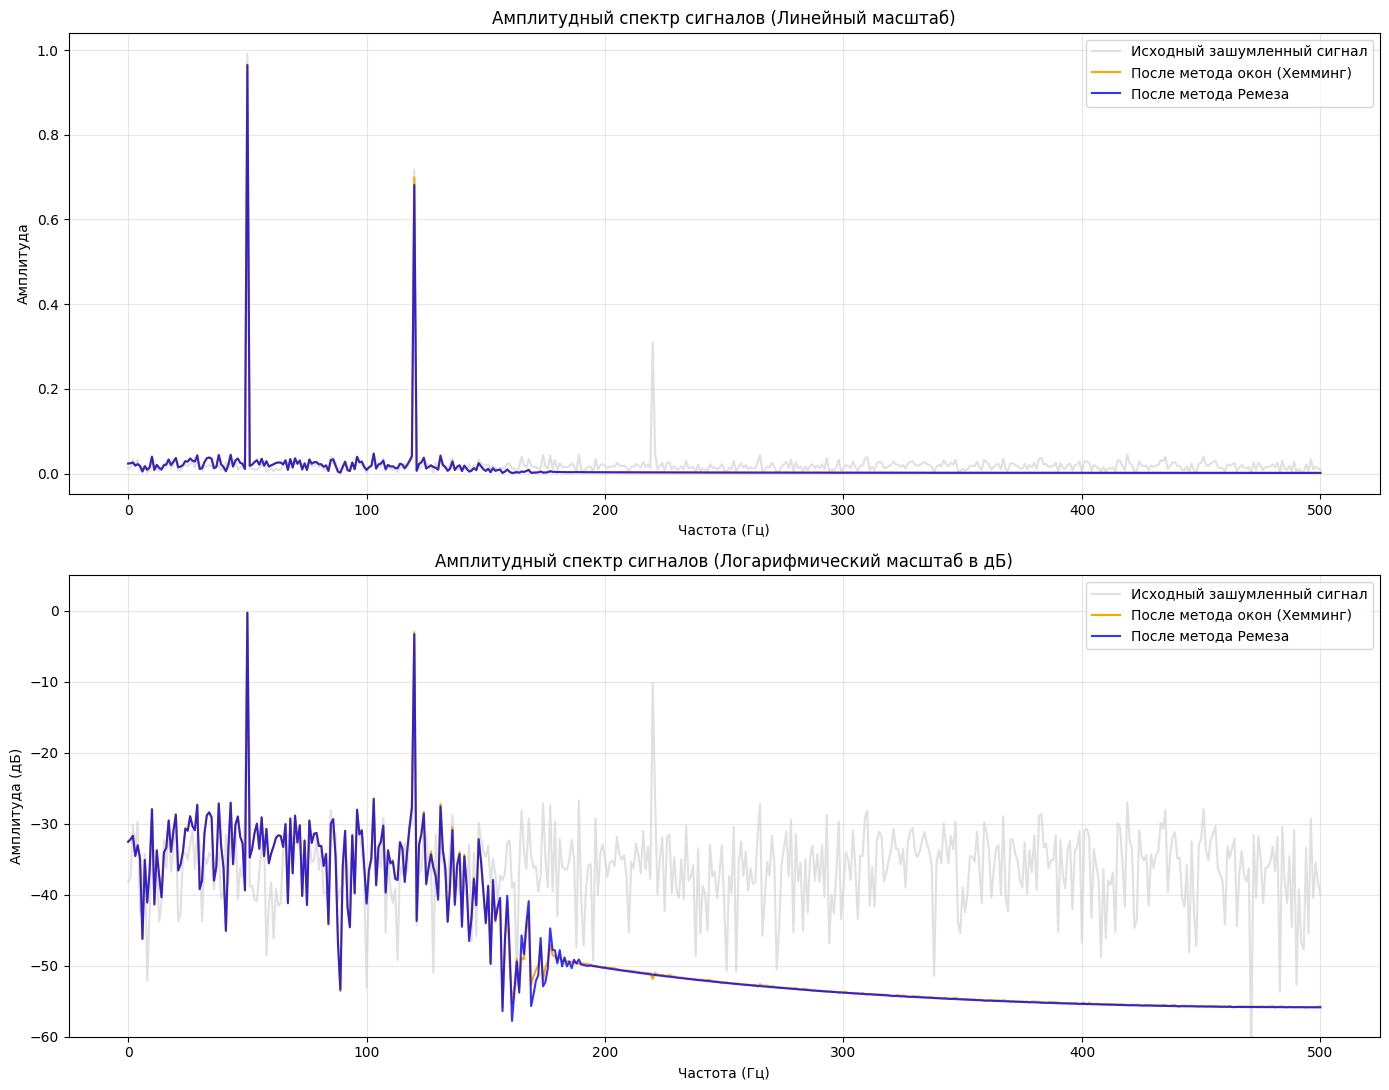

In [8]:
numtaps = 51
t = np.linspace(0, 1, fs, endpoint=False)

np.random.seed(42)
x_clean = (1.0 * np.sin(2 * np.pi * 50 * t) +
           0.7 * np.sin(2 * np.pi * 120 * t) +
           0.3 * np.sin(2 * np.pi * 220 * t))
noise = np.random.normal(0, np.sqrt(0.1), len(t))
x_noisy = x_clean + noise

taps_window = signal.firwin(numtaps, cutoff=150, fs=fs, window='hamming')

bands = [0, 100, 200, 500]
desired = [1, 0]
taps_remez = signal.remez(numtaps, bands, desired, fs=fs)

y_window = signal.lfilter(taps_window, [1], x_noisy)
y_remez = signal.lfilter(taps_remez, [1], x_noisy)

freqs = np.fft.rfftfreq(len(t), d=1/fs)

def calc_spectra(sig):
    mag = np.abs(np.fft.rfft(sig)) / len(sig) * 2
    mag_db = 20 * np.log10(mag + 1e-5)
    return mag, mag_db

mag_in, db_in = calc_spectra(x_noisy)
mag_win, db_win = calc_spectra(y_window)
mag_rem, db_rem = calc_spectra(y_remez)

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(14, 11))

ax1.plot(freqs, mag_in, color='lightgray', alpha=0.7, label='Исходный зашумленный сигнал')
ax1.plot(freqs, mag_win, color='orange', lw=1.5, label='После метода окон (Хемминг)')
ax1.plot(freqs, mag_rem, color='blue', lw=1.5, alpha=0.8, label='После метода Ремеза')
ax1.set_title('Амплитудный спектр сигналов (Линейный масштаб)')
ax1.set_xlabel('Частота (Гц)')
ax1.set_ylabel('Амплитуда')
ax1.grid(True, alpha=0.3)
ax1.legend()

ax2.plot(freqs, db_in, color='lightgray', alpha=0.7, label='Исходный зашумленный сигнал')
ax2.plot(freqs, db_win, color='orange', lw=1.5, label='После метода окон (Хемминг)')
ax2.plot(freqs, db_rem, color='blue', lw=1.5, alpha=0.8, label='После метода Ремеза')
ax2.set_title('Амплитудный спектр сигналов (Логарифмический масштаб в дБ)')
ax2.set_xlabel('Частота (Гц)')
ax2.set_ylabel('Амплитуда (дБ)')
ax2.set_ylim(-60, 5)
ax2.grid(True, which="both", alpha=0.3)
ax2.legend()

plt.tight_layout()
plt.show()

**Вопросы:** Какой фильтр лучше подавил 220 Гц и шум? Какой лучше сохранил 120 Гц? На сколько отличаются амплитуды 120 Гц сигнала от исходных для каждого из фильтров?


Оптимальный фильтр Ремеза лучше подавил 220 Гц и шум, Фильтр оконного метода Хемминга лучше сохранил 120 Гц. Для оконного фильтра отличие от исходного составляет около  0  дБ, для оптимального фильтра отличие от исходного сставляет порядка  −3.5  дБ

## Часть 3. Синтез БИХ-фильтров

### Задание 3.1. Баттерворт, Чебышев, эллиптический – сравнение АЧХ
Спроектируйте ФНЧ с частотой среза 200 Гц (fs=1000 Гц) следующих типов (порядок 4):
- Баттерворт (`butter`);
- Чебышев I с пульсациями 1 дБ (`cheby1`);
- Чебышев II с затуханием 40 дБ в полосе заграждения (`cheby2`);
- Эллиптический с пульсациями 1 дБ и затуханием 40 дБ (`ellip`).

Постройте АЧХ всех фильтров на одном графике (в дБ). Сравните:
- крутизну среза,
- пульсации в полосе пропускания и заграждения.

Постройте и сравните фазовые характеристики (ФЧХ) и групповые задержки.


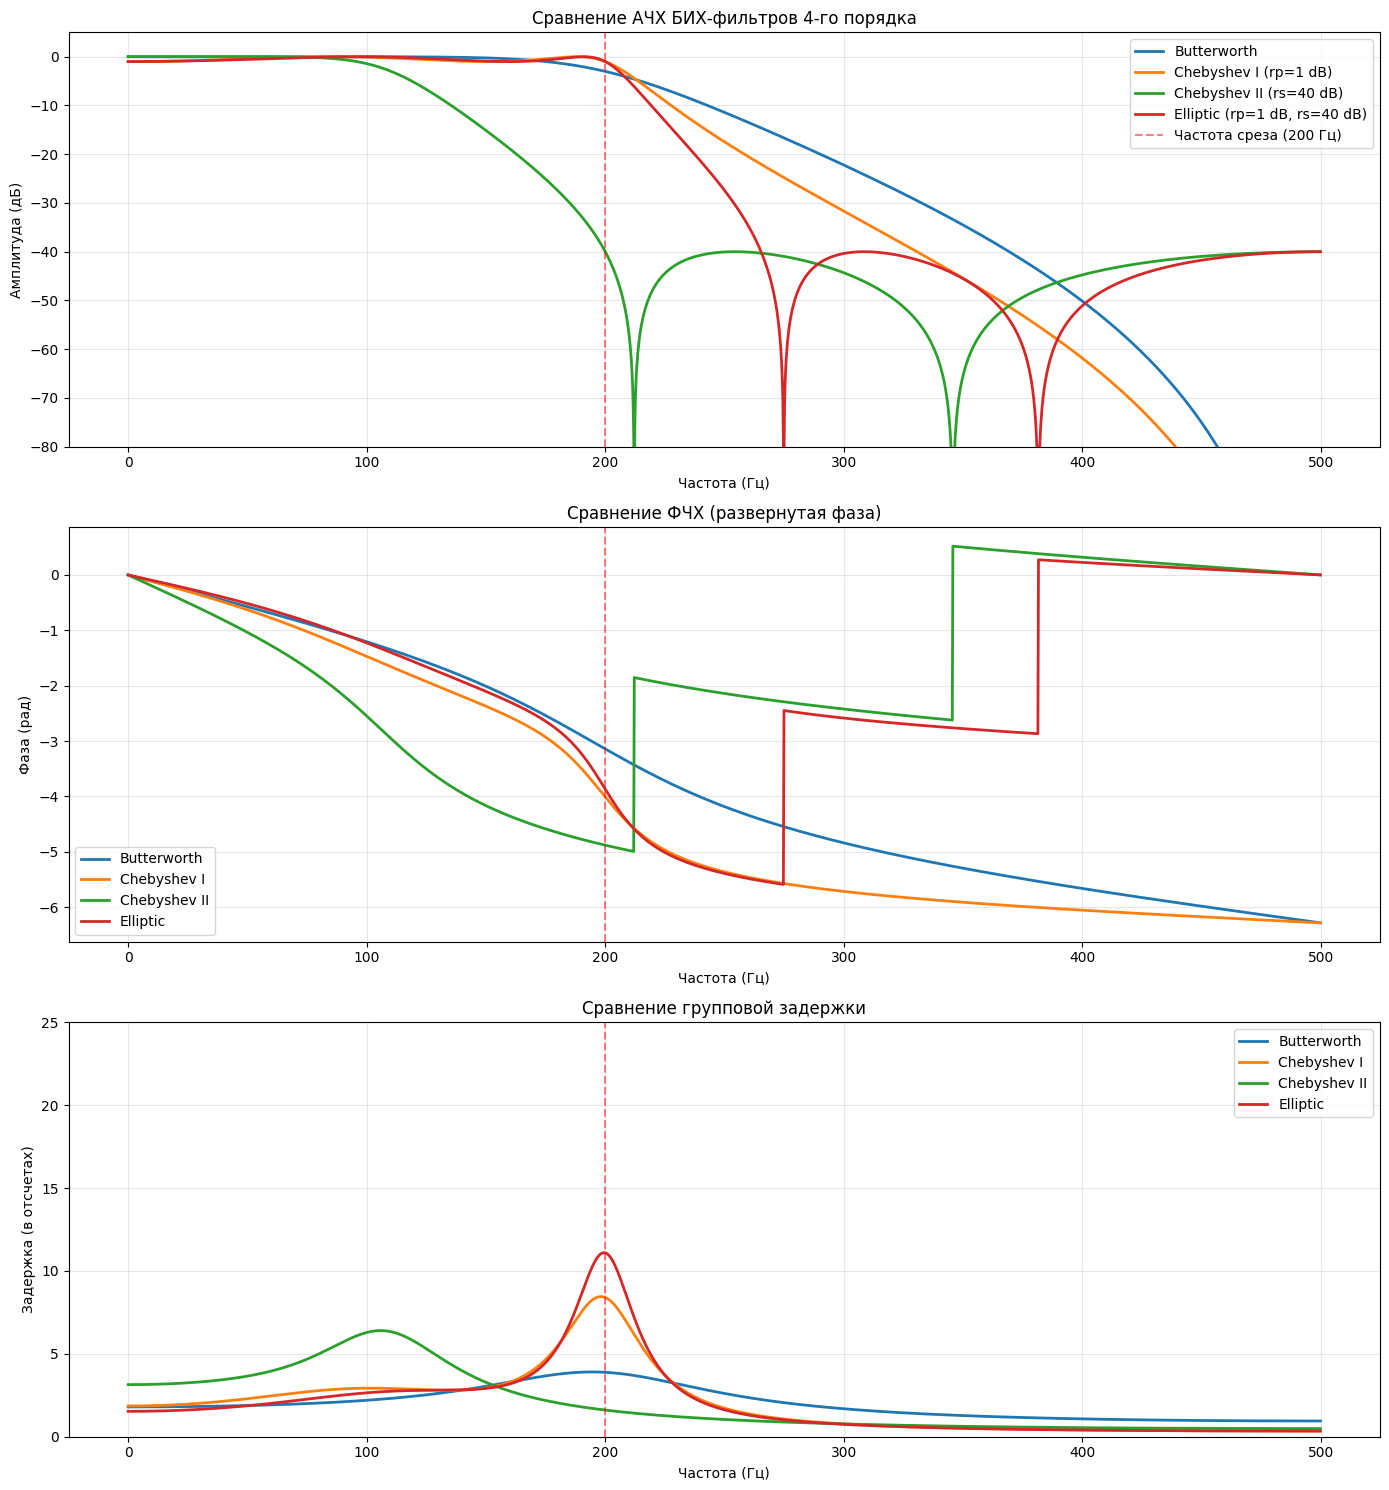

In [9]:
fs = 1000
N = 4
fc = 200  # Частота среза

sos_butter = signal.butter(N, fc, btype='low', fs=fs, output='sos')
sos_cheby1 = signal.cheby1(N, 1, fc, btype='low', fs=fs, output='sos')       # rp = 1 дБ
sos_cheby2 = signal.cheby2(N, 40, fc, btype='low', fs=fs, output='sos')      # rs = 40 дБ
sos_ellip  = signal.ellip(N, 1, 40, fc, btype='low', fs=fs, output='sos')    # rp = 1 дБ, rs = 40 дБ

w, h_butter = signal.sosfreqz(sos_butter, worN=2048, fs=fs)
_, h_cheby1 = signal.sosfreqz(sos_cheby1, worN=2048, fs=fs)
_, h_cheby2 = signal.sosfreqz(sos_cheby2, worN=2048, fs=fs)
_, h_ellip  = signal.sosfreqz(sos_ellip, worN=2048, fs=fs)

w_gd, gd_butter = signal.group_delay(signal.sos2tf(sos_butter), w=2048, fs=fs)
_, gd_cheby1    = signal.group_delay(signal.sos2tf(sos_cheby1), w=2048, fs=fs)
_, gd_cheby2    = signal.group_delay(signal.sos2tf(sos_cheby2), w=2048, fs=fs)
_, gd_ellip     = signal.group_delay(signal.sos2tf(sos_ellip), w=2048, fs=fs)

plt.figure(figsize=(14, 15))

# График 1: АЧХ (в дБ)
plt.subplot(3, 1, 1)
plt.plot(w, 20 * np.log10(np.abs(h_butter) + 1e-6), label='Butterworth', lw=2)
plt.plot(w, 20 * np.log10(np.abs(h_cheby1) + 1e-6), label='Chebyshev I (rp=1 dB)', lw=2)
plt.plot(w, 20 * np.log10(np.abs(h_cheby2) + 1e-6), label='Chebyshev II (rs=40 dB)', lw=2)
plt.plot(w, 20 * np.log10(np.abs(h_ellip) + 1e-6), label='Elliptic (rp=1 dB, rs=40 dB)', lw=2)
plt.axvline(fc, color='red', linestyle='--', alpha=0.5, label='Частота среза (200 Гц)')
plt.title('Сравнение АЧХ БИХ-фильтров 4-го порядка')
plt.xlabel('Частота (Гц)')
plt.ylabel('Амплитуда (дБ)')
plt.ylim(-80, 5)
plt.grid(True, which='both', alpha=0.3)
plt.legend()

# График 2: ФЧХ (Фазо-частотная характеристика)
plt.subplot(3, 1, 2)
plt.plot(w, np.unwrap(np.angle(h_butter)), label='Butterworth', lw=2)
plt.plot(w, np.unwrap(np.angle(h_cheby1)), label='Chebyshev I', lw=2)
plt.plot(w, np.unwrap(np.angle(h_cheby2)), label='Chebyshev II', lw=2)
plt.plot(w, np.unwrap(np.angle(h_ellip)), label='Elliptic', lw=2)
plt.axvline(fc, color='red', linestyle='--', alpha=0.5)
plt.title('Сравнение ФЧХ (развернутая фаза)')
plt.xlabel('Частота (Гц)')
plt.ylabel('Фаза (рад)')
plt.grid(True, alpha=0.3)
plt.legend()

# График 3: Групповая задержка (Group Delay)
plt.subplot(3, 1, 3)
plt.plot(w_gd, gd_butter, label='Butterworth', lw=2)
plt.plot(w_gd, gd_cheby1, label='Chebyshev I', lw=2)
plt.plot(w_gd, gd_cheby2, label='Chebyshev II', lw=2)
plt.plot(w_gd, gd_ellip, label='Elliptic', lw=2)
plt.axvline(fc, color='red', linestyle='--', alpha=0.5)
plt.title('Сравнение групповой задержки')
plt.xlabel('Частота (Гц)')
plt.ylabel('Задержка (в отсчетах)')
plt.ylim(0, 25)  # Ограничим для наглядности пиков
plt.grid(True, alpha=0.3)
plt.legend()

plt.tight_layout()
plt.show()

**Вопросы:** Какой фильтр даёт самый крутой спад? Какой имеет наименьшие фазовые искажения в полосе пропускания?


Эллиптический фильтр даёт самый крутой спад, Фильтр Баттерворта имеет наименьшие фазовые искажения в полосе пропускания

### Задание 3.2. Влияние порядка на характеристики БИХ-фильтра
Для фильтра Баттерворта с fc=200 Гц, fs=1000 Гц возьмите порядки 2, 4, 6. Постройте АЧХ и групповую задержку.


/tmp/ipykernel_21178/2928301472.py:17: UserWarning: The filter's denominator is extremely small at frequencies [3.137, 3.139, 3.140], around which a singularity may be present
  w_gd, gd = signal.group_delay(signal.sos2tf(sos), w=2048, fs=fs)


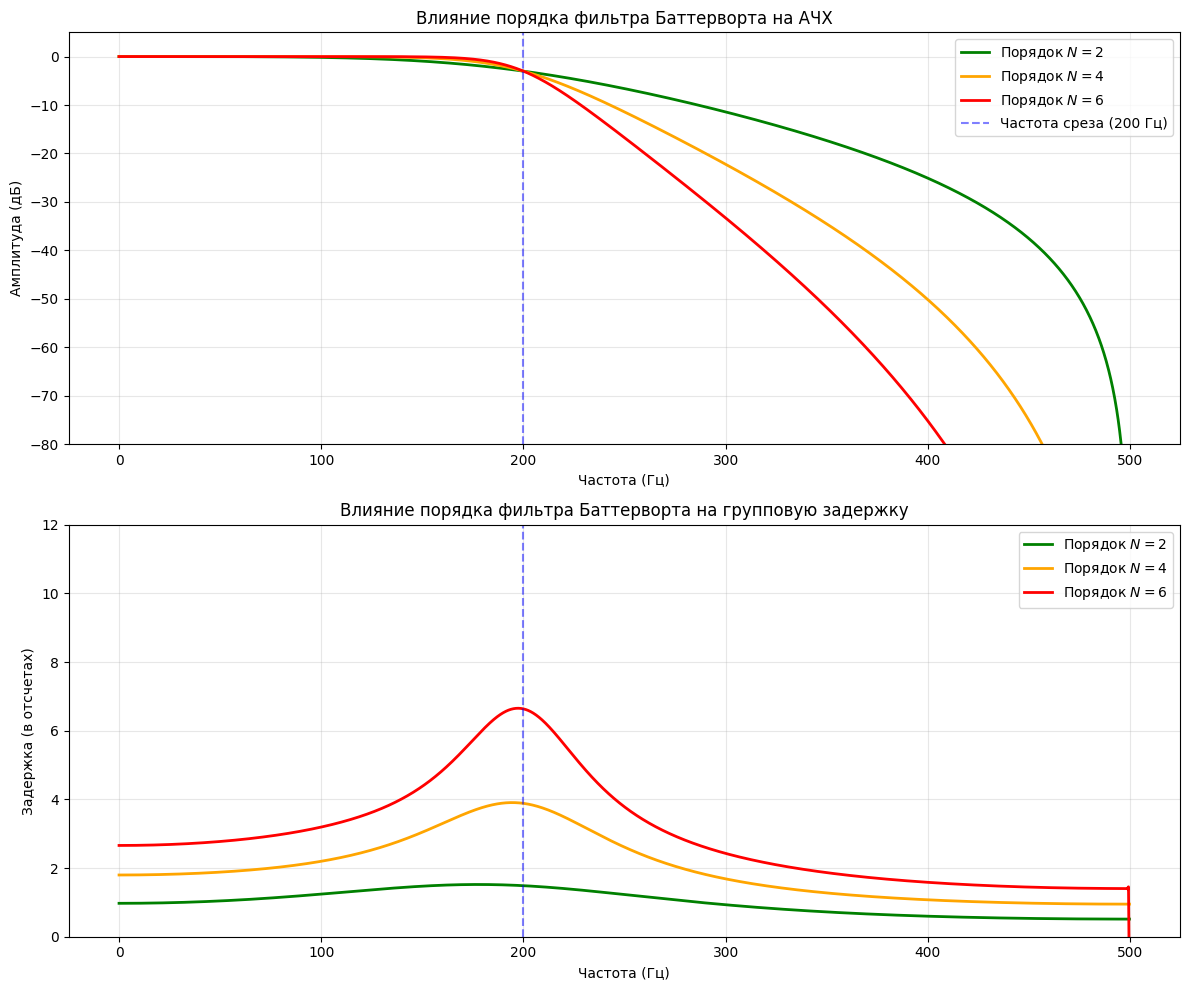

In [10]:
orders = [2, 4, 6]

ach_results = {}
gd_results = {}

for N in orders:
    sos = signal.butter(N, fc, btype='low', fs=fs, output='sos')
    w, h = signal.sosfreqz(sos, worN=2048, fs=fs)
    ach_results[N] = 20 * np.log10(np.abs(h) + 1e-6)
    w_gd, gd = signal.group_delay(signal.sos2tf(sos), w=2048, fs=fs)
    gd_results[N] = gd

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(12, 10))

# График АЧХ
colors = {2: 'green', 4: 'orange', 6: 'red'}
for N in orders:
    ax1.plot(w, ach_results[N], color=colors[N], lw=2, label=r'Порядок $N={}$'.format(N))
ax1.axvline(fc, color='blue', linestyle='--', alpha=0.5, label='Частота среза (200 Гц)')
ax1.set_title('Влияние порядка фильтра Баттерворта на АЧХ')
ax1.set_xlabel('Частота (Гц)')
ax1.set_ylabel('Амплитуда (дБ)')
ax1.set_ylim(-80, 5)
ax1.grid(True, which='both', alpha=0.3)
ax1.legend()

# График групповой задержки
for N in orders:
    ax2.plot(w_gd, gd_results[N], color=colors[N], lw=2, label=r'Порядок $N={}$'.format(N))
ax2.axvline(fc, color='blue', linestyle='--', alpha=0.5)
ax2.set_title('Влияние порядка фильтра Баттерворта на групповую задержку')
ax2.set_xlabel('Частота (Гц)')
ax2.set_ylabel('Задержка (в отсчетах)')
ax2.set_ylim(0, 12)
ax2.grid(True, alpha=0.3)
ax2.legend()

plt.tight_layout()
plt.show()

**Вопросы:** Как увеличение порядка влияет на крутизну среза и на групповую задержку в полосе пропускания?

С увеличением порядка фильтра крутизна среза в переходной полосе существенно возрастает. Увеличение порядка фильтра приводит к росту абсолютной величины задержки и увеличение неравномерности

### Задание 3.3. Преобразование типа БИХ-фильтра (ФНЧ → ФВЧ, полосовой)
Спроектируйте Баттерворта 4-го порядка:
- ФНЧ с fc=200 Гц;
- ФВЧ с fc=200 Гц (используйте `btype='high'`);
- полосовой с полосой 200–300 Гц.

Подайте на них сигнал: сумма синусоид 100, 250, 400 Гц. Постройте спектры после фильтрации.


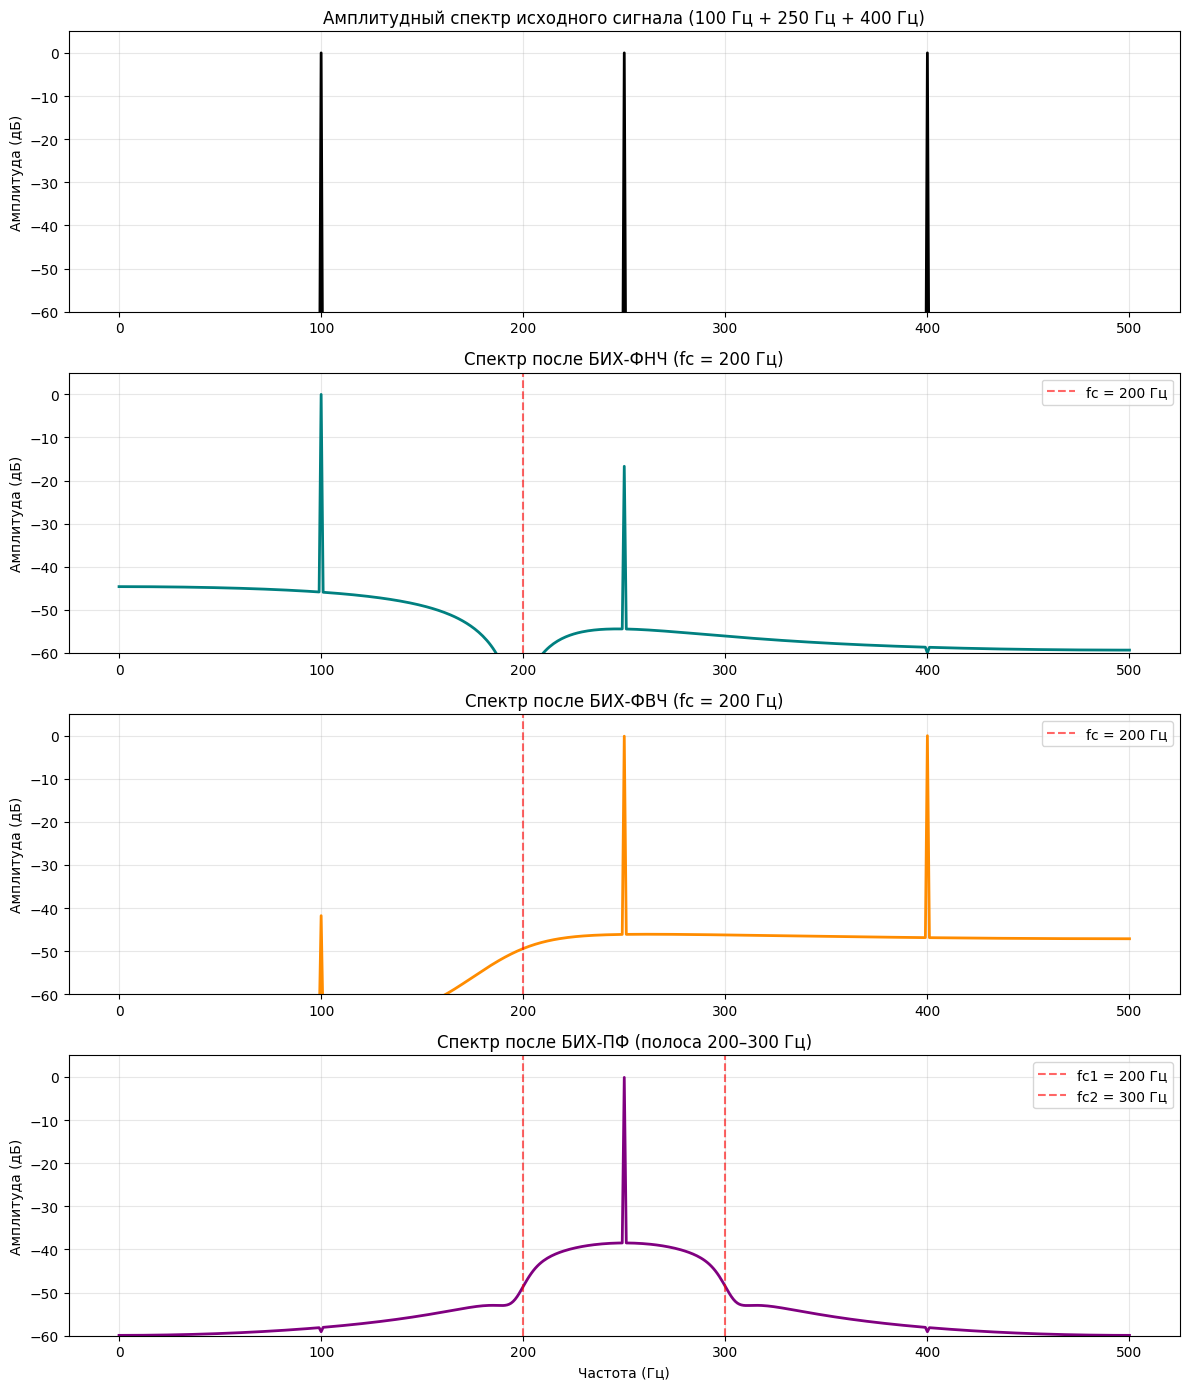

In [12]:
t = np.linspace(0, 1, fs, endpoint=False)  # 1 секунда сигнала

x = np.sin(2 * np.pi * 100 * t) + np.sin(2 * np.pi * 250 * t) + np.sin(2 * np.pi * 400 * t)

sos_low  = signal.butter(N, 200, btype='low', fs=fs, output='sos')
sos_high = signal.butter(N, 200, btype='high', fs=fs, output='sos')
sos_band = signal.butter(N, [200, 300], btype='bandpass', fs=fs, output='sos')

y_low  = signal.sosfilt(sos_low, x)
y_high = signal.sosfilt(sos_high, x)
y_band = signal.sosfilt(sos_band, x)

freqs = np.fft.rfftfreq(len(t), d=1/fs)

def get_db_spectrum(sig):
    mag = np.abs(np.fft.rfft(sig)) / len(sig) * 2
    return 20 * np.log10(mag + 1e-5)

spec_in   = get_db_spectrum(x)
spec_low  = get_db_spectrum(y_low)
spec_high = get_db_spectrum(y_high)
spec_band = get_db_spectrum(y_band)

# 5. Визуализация спектров
plt.figure(figsize=(12, 14))

# Исходный спектр
plt.subplot(4, 1, 1)
plt.plot(freqs, spec_in, color='black', lw=2)
plt.title('Амплитудный спектр исходного сигнала (100 Гц + 250 Гц + 400 Гц)')
plt.ylabel('Амплитуда (дБ)')
plt.ylim(-60, 5)
plt.grid(True, alpha=0.3)

# Спектр после ФНЧ
plt.subplot(4, 1, 2)
plt.plot(freqs, spec_low, color='teal', lw=2)
plt.axvline(200, color='red', linestyle='--', alpha=0.6, label='fc = 200 Гц')
plt.title('Спектр после БИХ-ФНЧ (fc = 200 Гц)')
plt.ylabel('Амплитуда (дБ)')
plt.ylim(-60, 5)
plt.grid(True, alpha=0.3)
plt.legend()

# Спектр после ФВЧ
plt.subplot(4, 1, 3)
plt.plot(freqs, spec_high, color='darkorange', lw=2)
plt.axvline(200, color='red', linestyle='--', alpha=0.6, label='fc = 200 Гц')
plt.title('Спектр после БИХ-ФВЧ (fc = 200 Гц)')
plt.ylabel('Амплитуда (дБ)')
plt.ylim(-60, 5)
plt.grid(True, alpha=0.3)
plt.legend()

# Спектр после полосового фильтра
plt.subplot(4, 1, 4)
plt.plot(freqs, spec_band, color='purple', lw=2)
plt.axvline(200, color='red', linestyle='--', alpha=0.6, label='fc1 = 200 Гц')
plt.axvline(300, color='red', linestyle='--', alpha=0.6, label='fc2 = 300 Гц')
plt.title('Спектр после БИХ-ПФ (полоса 200–300 Гц)')
plt.xlabel('Частота (Гц)')
plt.ylabel('Амплитуда (дБ)')
plt.ylim(-60, 5)
plt.grid(True, alpha=0.3)
plt.legend()

plt.tight_layout()
plt.show()

**Вопрос:** Какие составляющие подавлены, а какие пропущены в каждом случае?

1. БИХ-ФНЧ


*   Пропущена: Составляющая 100 Гц. На графике виден её полноценный пик на уровне 0 дБ.
*   Подавлена: Составляющая 400 Гц. Она находится глубоко в зоне заграждения и подавлена практически до уровня полки сглаживания (ниже $-55$ дБ).

2. БИХ-ФВЧ

*   Пропущены: Составляющие 250 Гц и 400 Гц. Оба пика находятся на уровне 0 дБ, то есть прошли через фильтр без каких-либо потерь амплитуды.
*   Подавлена: Составляющая 100 Гц. Она успешно отрезана фильтром, и её остаточный пик опустился до отметки около $-41$ дБ.

3. БИХ-ПФ


*   Пропущена: Составляющая 250 Гц. Она идеально попадает в центр полосы пропускания ($200 \dots 300$ Гц), поэтому её пик остался нетронутым на уровне 0 дБ.
*   Подавлены:  Составляющая 100 Гц — полностью вырезана левой зоной заграждения (ушла на уровень $-58$ дБ).


### Задание 3.4. Применение БИХ-фильтра к зашумлённому сигналу
Сгенерируйте сигнал: синусоида 50 Гц + белый шум с дисперсией 0.2, fs=1000 Гц, длительность 1 с. Спроектируйте эллиптический ФНЧ с fc=100 Гц (порядок 6, пульсации 1 дБ, затухание 40 дБ). Примените фильтр с помощью `lfilter` и `filtfilt`. Постройте на одном графике исходный и отфильтрованные сигналы (временные области, первые 0.2 с), а также их спектры. Сравните задержку и подавление шума.


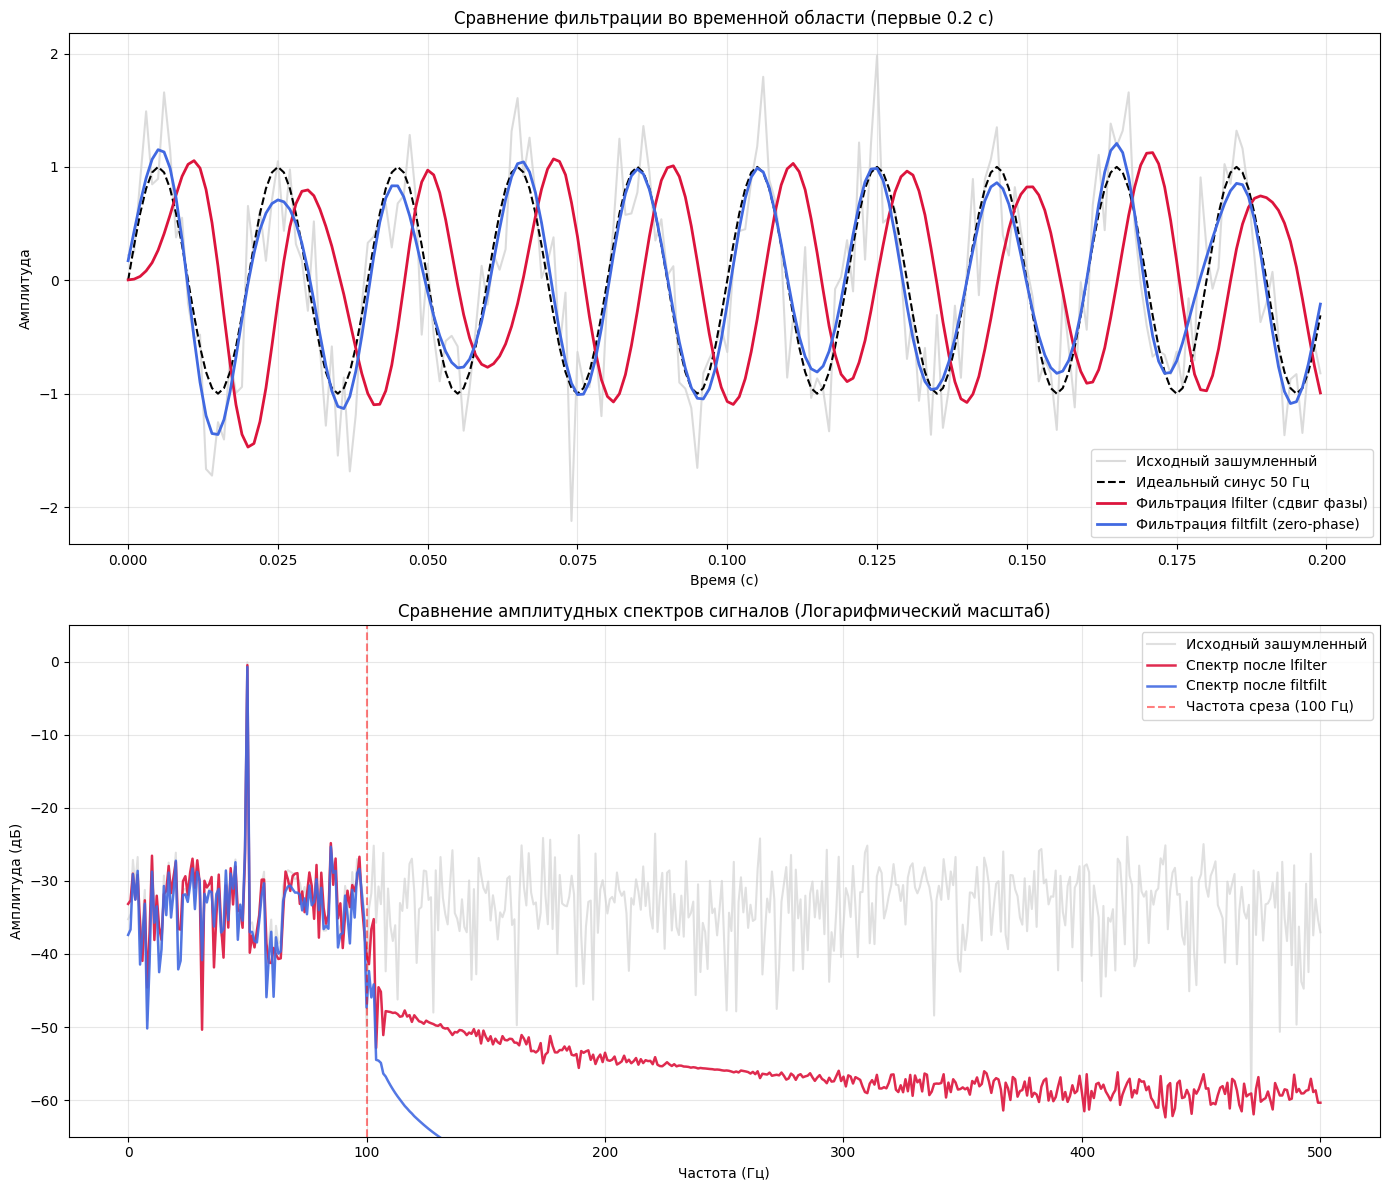

In [13]:
duration = 1.0
t = np.linspace(0, duration, int(fs * duration), endpoint=False)

np.random.seed(42)
x_clean = np.sin(2 * np.pi * 50 * t)
noise = np.random.normal(0, np.sqrt(0.2), len(t))
x_noisy = x_clean + noise

b, a = signal.ellip(6, 1, 40, 100, btype='low', fs=fs, output='ba')

# 3. Фильтрация
y_lfilter = signal.lfilter(b, a, x_noisy)
y_filtfilt = signal.filtfilt(b, a, x_noisy)

freqs = np.fft.rfftfreq(len(t), d=1/fs)

def get_db_spectrum(sig):
    mag = np.abs(np.fft.rfft(sig)) / len(sig) * 2
    return 20 * np.log10(mag + 1e-5)

spec_noisy = get_db_spectrum(x_noisy)
spec_lfilter = get_db_spectrum(y_lfilter)
spec_filtfilt = get_db_spectrum(y_filtfilt)

# 5. Визуализация результатов
plt.figure(figsize=(14, 12))

plt.subplot(2, 1, 1)
t_view = t[:200]
plt.plot(t_view, x_noisy[:200], color='lightgray', alpha=0.8, label='Исходный зашумленный')
plt.plot(t_view, x_clean[:200], color='black', linestyle='--', lw=1.5, label='Идеальный синус 50 Гц')
plt.plot(t_view, y_lfilter[:200], color='crimson', lw=2, label='Фильтрация lfilter (сдвиг фазы)')
plt.plot(t_view, y_filtfilt[:200], color='royalblue', lw=2, label='Фильтрация filtfilt (zero-phase)')

plt.title('Сравнение фильтрации во временной области (первые 0.2 с)')
plt.xlabel('Время (с)')
plt.ylabel('Амплитуда')
plt.grid(True, alpha=0.3)
plt.legend()

# --- График 2: Частотная область (Спектры в дБ) ---
plt.subplot(2, 1, 2)
plt.plot(freqs, spec_noisy, color='lightgray', alpha=0.7, label='Исходный зашумленный')
plt.plot(freqs, spec_lfilter, color='crimson', lw=1.8, alpha=0.9, label='Спектр после lfilter')
plt.plot(freqs, spec_filtfilt, color='royalblue', lw=1.8, alpha=0.9, label='Спектр после filtfilt')
plt.axvline(100, color='red', linestyle='--', alpha=0.5, label='Частота среза (100 Гц)')

plt.title('Сравнение амплитудных спектров сигналов (Логарифмический масштаб)')
plt.xlabel('Частота (Гц)')
plt.ylabel('Амплитуда (дБ)')
plt.ylim(-65, 5)
plt.grid(True, which='both', alpha=0.3)
plt.legend()

plt.tight_layout()
plt.show()

**Вопрос:** Почему `filtfilt` даёт нулевой фазовый сдвиг?

Достигается за счет двунаправленной фильтрации.

*  Двунаправленная обработка (вперёд+назад)
*  Нулевая фаза, сигнал не смещается по времени


## Часть 4. Сравнение КИХ и БИХ фильтров одинакового порядка

### Задание 4.1. Сравнение характеристик
Спроектируйте:
- КИХ-ФНЧ методом окон (окно Хемминга, длина 51, fc=200 Гц);
- БИХ-ФНЧ Баттерворта 4-го порядка (fc=200 Гц).

Постройте для них на одном графике:
- отдельно АЧХ (в дБ),
- отдельно групповую задержку.


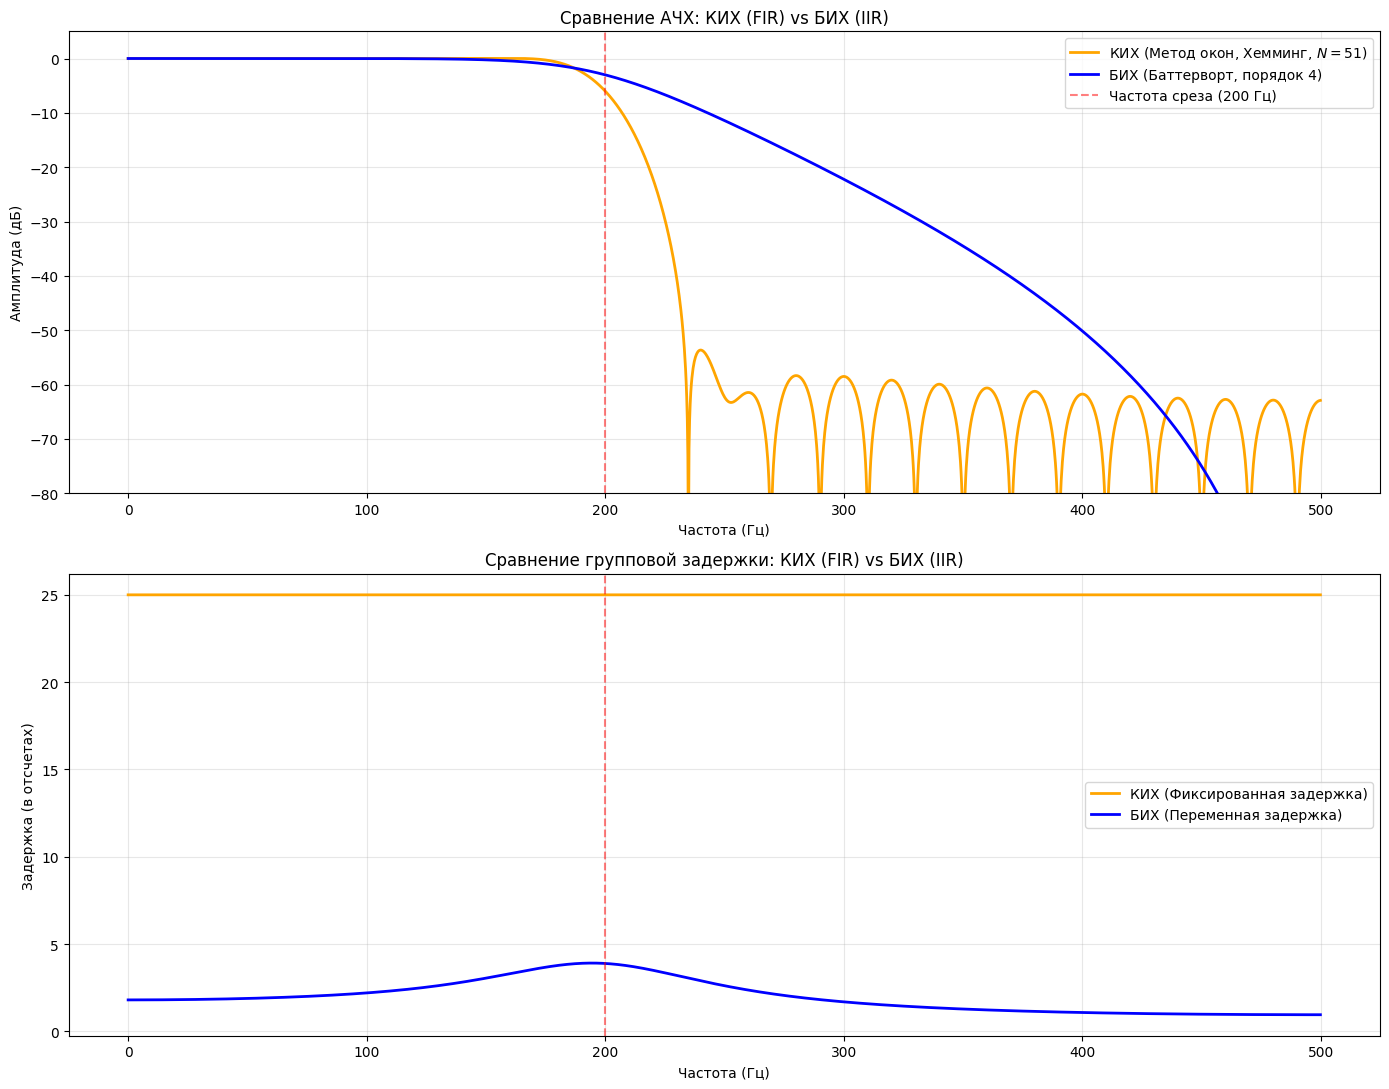

In [14]:
fs = 1000
fc = 200

numtaps = 51
taps_fir = signal.firwin(numtaps, cutoff=fc, window='hamming', fs=fs)
w_fir, h_fir = signal.freqz(taps_fir, [1], worN=2048, fs=fs)
w_gd_fir, gd_fir = signal.group_delay((taps_fir, [1]), w=2048, fs=fs)

N_iir = 4
sos_iir = signal.butter(N_iir, fc, btype='low', fs=fs, output='sos')
w_iir, h_iir = signal.sosfreqz(sos_iir, worN=2048, fs=fs)
w_gd_iir, gd_iir = signal.group_delay(signal.sos2tf(sos_iir), w=2048, fs=fs)

plt.figure(figsize=(14, 11))

# График 1: Сравнение АЧХ (в дБ)
plt.subplot(2, 1, 1)
plt.plot(w_fir, 20 * np.log10(np.abs(h_fir) + 1e-6), color='orange', lw=2, label='КИХ (Метод окон, Хемминг, $N=51$)')
plt.plot(w_iir, 20 * np.log10(np.abs(h_iir) + 1e-6), color='blue', lw=2, label='БИХ (Баттерворт, порядок 4)')
plt.axvline(fc, color='red', linestyle='--', alpha=0.5, label='Частота среза (200 Гц)')
plt.title('Сравнение АЧХ: КИХ (FIR) vs БИХ (IIR)')
plt.xlabel('Частота (Гц)')
plt.ylabel('Амплитуда (дБ)')
plt.ylim(-80, 5)
plt.grid(True, which='both', alpha=0.3)
plt.legend()

# График 2: Сравнение групповой задержки (Group Delay)
plt.subplot(2, 1, 2)
plt.plot(w_gd_fir, gd_fir, color='orange', lw=2, label='КИХ (Фиксированная задержка)')
plt.plot(w_gd_iir, gd_iir, color='blue', lw=2, label='БИХ (Переменная задержка)')
plt.axvline(fc, color='red', linestyle='--', alpha=0.5)
plt.title('Сравнение групповой задержки: КИХ (FIR) vs БИХ (IIR)')
plt.xlabel('Частота (Гц)')
plt.ylabel('Задержка (в отсчетах)')
plt.grid(True, alpha=0.3)
plt.legend()

plt.tight_layout()
plt.show()

**Вопросы:** Какой фильтр имеет более крутой срез? Какой имеет постоянную групповую задержку? Какой вносит меньшие фазовые искажения? Какой требует меньше вычислений? Попробуйте увеличить порядок фильтра Баттерворта. При каком порядке крутизна среза его АЧХ становится сравнимой с КИХ-фильтром? Растут или уменьшаются при этом фазовые искажения?


Какой фильтр имеет более крутой срез?
КИХ-фильтр.

 Какой имеет постоянную групповую задержку?
КИХ-фильтр.

Какой вносит меньшие фазовые искажения?
КИХ-фильтр.

Какой требует меньше вычислений?
БИХ-фильтр.

Крутизна среза АЧХ Баттерворта становится сравнимой с КИХ при порядке N = 20, фазовые искажения БИХ-фильтра при этом резко возрастают.



### Задание 4.2. Применение к реальному сигналу
Сгенерируйте сигнал: короткий прямоугольный импульс длительностью 10 мс, а также высокочастотная синусоидальная помеха 400 Гц. Частоту дискретизации возьмите fs=10000 Гц.

Примените оба фильтра (КИХ и БИХ из предыдущего пункта). Постройте исходный и отфильтрованные сигналы.


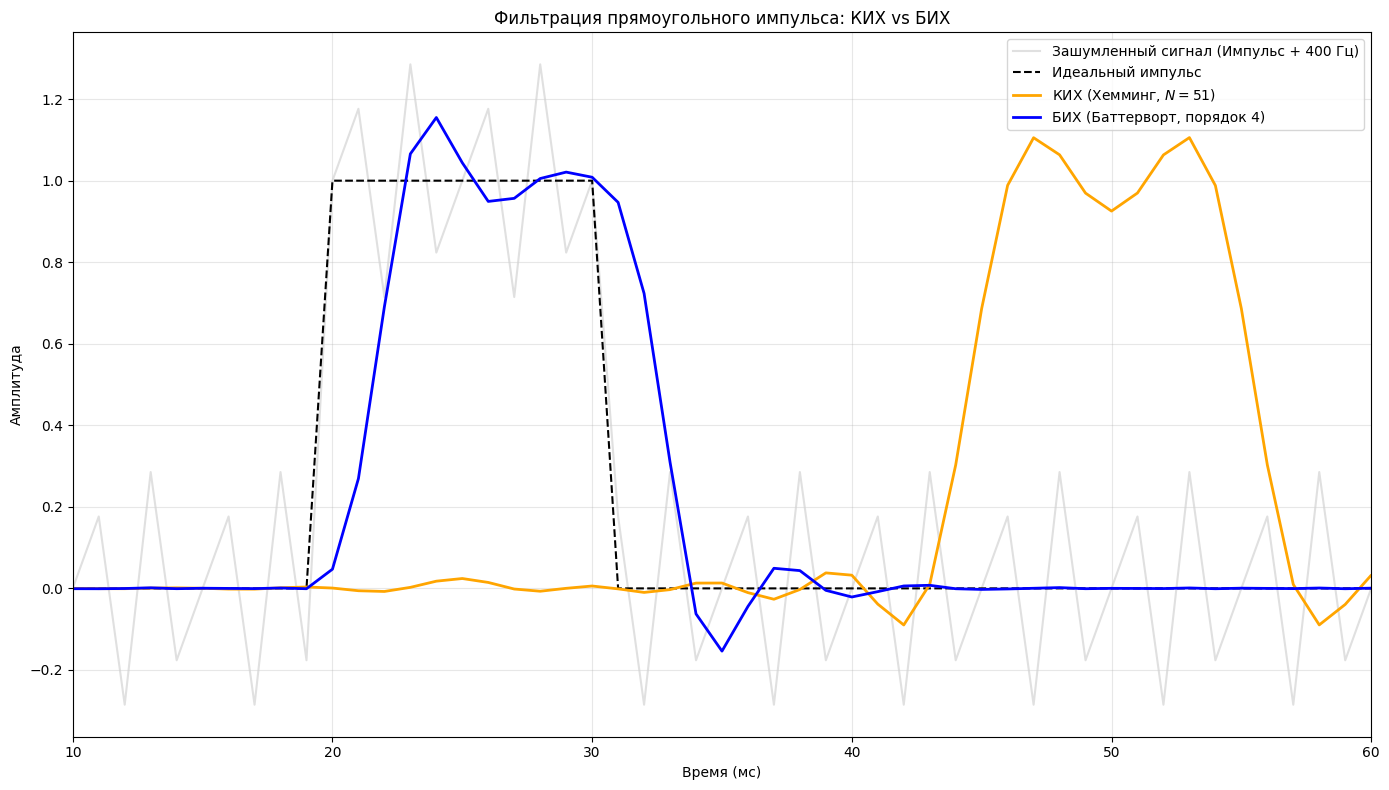

In [15]:
x_pulse = np.zeros_like(t)
x_pulse[(t >= 0.02) & (t <= 0.03)] = 1.0

fc_noise = 400
noise = 0.3 * np.sin(2 * np.pi * fc_noise * t)

x_noisy = x_pulse + noise

numtaps = 51
taps_fir = signal.firwin(numtaps, cutoff=200, window='hamming', fs=fs)

N_iir = 4
sos_iir = signal.butter(N_iir, 200, btype='low', fs=fs, output='sos')

y_fir = signal.lfilter(taps_fir, [1], x_noisy)
y_iir = signal.sosfilt(sos_iir, x_noisy)

plt.figure(figsize=(14, 8))

plt.plot(t * 1000, x_noisy, color='lightgray', alpha=0.7, label='Зашумленный сигнал (Импульс + 400 Гц)')
plt.plot(t * 1000, x_pulse, color='black', linestyle='--', lw=1.5, label='Идеальный импульс')
plt.plot(t * 1000, y_fir, color='orange', lw=2, label='КИХ (Хемминг, $N=51$)')
plt.plot(t * 1000, y_iir, color='blue', lw=2, label='БИХ (Баттерворт, порядок 4)')

plt.title('Фильтрация прямоугольного импульса: КИХ vs БИХ')
plt.xlabel('Время (мс)')
plt.ylabel('Амплитуда')
plt.xlim(10, 60)  # Крупный план на импульс (от 10 до 60 мс)
plt.grid(True, alpha=0.3)
plt.legend()

plt.tight_layout()
plt.show()

**Вопросы:** Какой фильтр лучше сохранил форму импульсов? Какой лучше подавил помеху?

КИХ-фильтр лучше сохранил форму импульсов КИХ-фильтр лучше подавил помеху